# Analyse des Ventes et Profits du Superstore

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Importation des Librairies et Chargement du Dataset

In [ ]:
data = pd.read_csv(r'C:\Users\2019\Downloads\Superstore\Superstore.csv',encoding='unicode_escape')

## 2. Exploration Initiale des Données

In [ ]:
data

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [ ]:
data.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
data.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

### 2.1 Vérification des Valeurs Manquantes et Statistiques Descriptives

In [ ]:
data.shape

(9994, 21)

In [ ]:
data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [ ]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 3. Analyse des Variables

In [ ]:
## Categoical Columns
df_cat=data[['Ship Mode','Customer ID','Customer Name','Segment','Country','City','State','Region','Product ID','Category','Sub-Category','Product Name']]

### 3.1 Variables Catégorielles

In [ ]:
for feature in df_cat.columns:
    print(feature,':',' ',df_cat[feature].nunique())

Ship Mode :   4
Customer ID :   793
Customer Name :   793
Segment :   3
Country :   1
City :   531
State :   49
Region :   4
Product ID :   1862
Category :   3
Sub-Category :   17
Product Name :   1850


In [ ]:
df_cat

,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
0,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...
3,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table
4,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System
...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle
9990,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...
9991,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone
9992,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5"""


### 3.2 Variables Numériques et Corrélation

In [ ]:
non_object_data=data.select_dtypes(exclude='object')
non_object_data

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
0,1,42420,261.9600,2,0.00,41.9136
1,2,42420,731.9400,3,0.00,219.5820
2,3,90036,14.6200,2,0.00,6.8714
3,4,33311,957.5775,5,0.45,-383.0310
4,5,33311,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...
9989,9990,33180,25.2480,3,0.20,4.1028
9990,9991,92627,91.9600,2,0.00,15.6332
9991,9992,92627,258.5760,2,0.20,19.3932
9992,9993,92627,29.6000,4,0.00,13.3200


In [ ]:
corr=non_object_data.corr()
corr

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000


<Axes: >

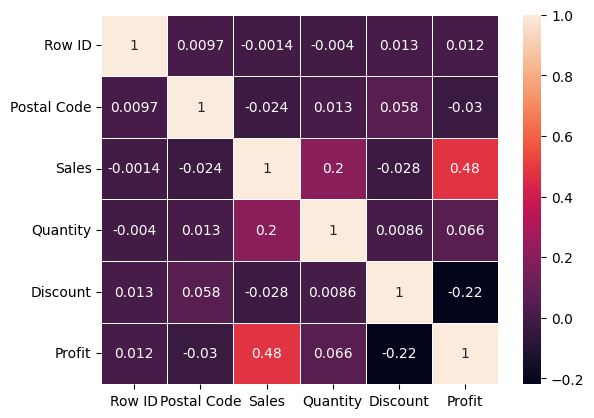

In [ ]:
sns.heatmap(corr,annot=True,linewidth=0.5)

## 4. Analyse des Produits les plus Vendus et les plus Rentables

In [ ]:
top5_selling_products=data.groupby(['Product Name'])[['Sales']].sum().sort_values(by='Sales' , ascending=False)[:5]
top5_selling_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479


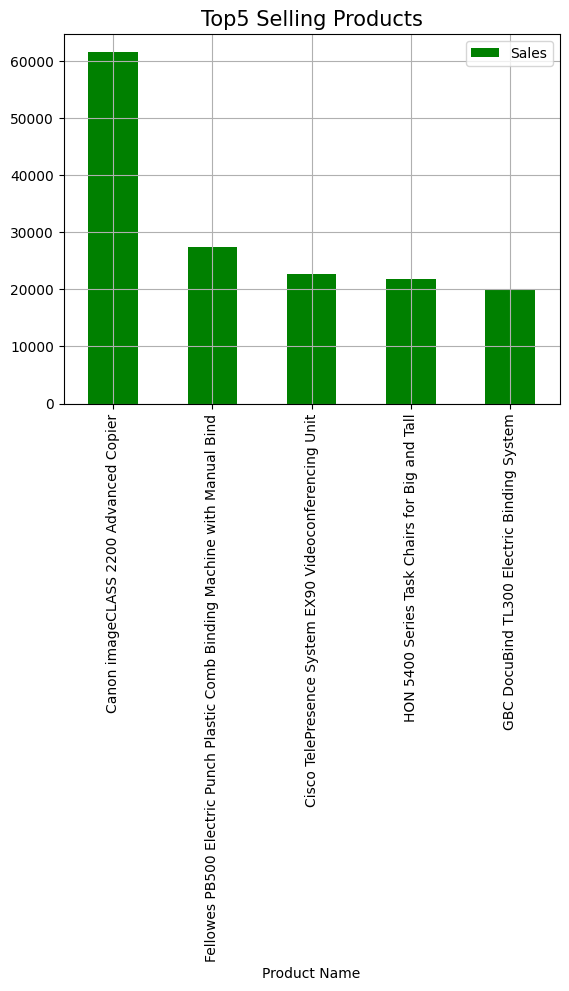

In [ ]:
top5_selling_products.plot(kind='bar',color='g')

plt.title('Top5 Selling Products',size=15)
plt.xlabel='Product Name'
plt.ylabel='Sales'
plt.grid()
plt.show()

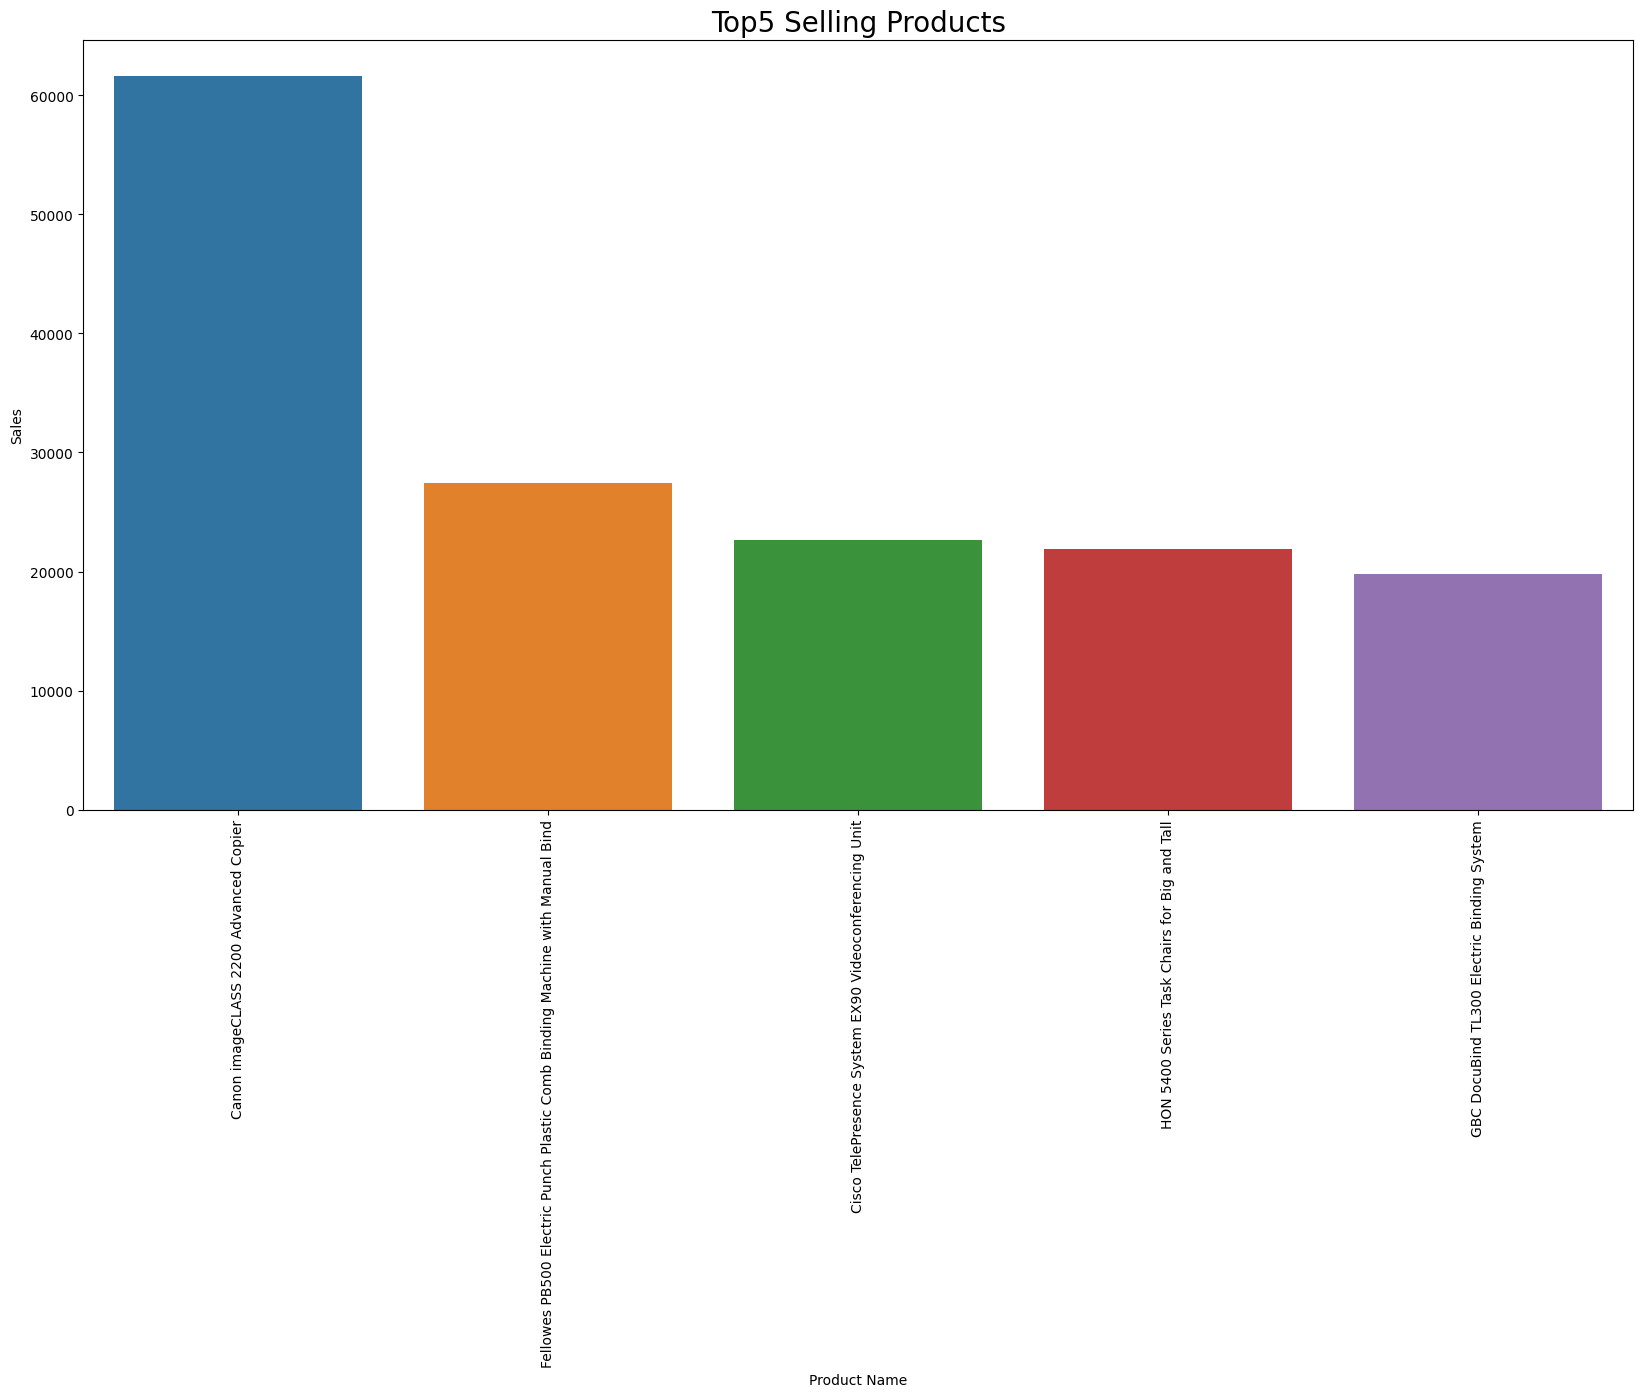

In [ ]:
plt.figure(figsize=(20,10))
sns.barplot(data=top5_selling_products, x='Product Name',y ='Sales',hue='Product Name')
plt.xticks(rotation=90)

plt.title('Top5 Selling Products',size=20)
plt.show()

In [ ]:
# Top 5 Profitabel Products
top_5_profit_products=data.groupby('Product Name')[['Profit']].sum().sort_values(by='Profit' , ascending=False)[:5]
top_5_profit_products

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766


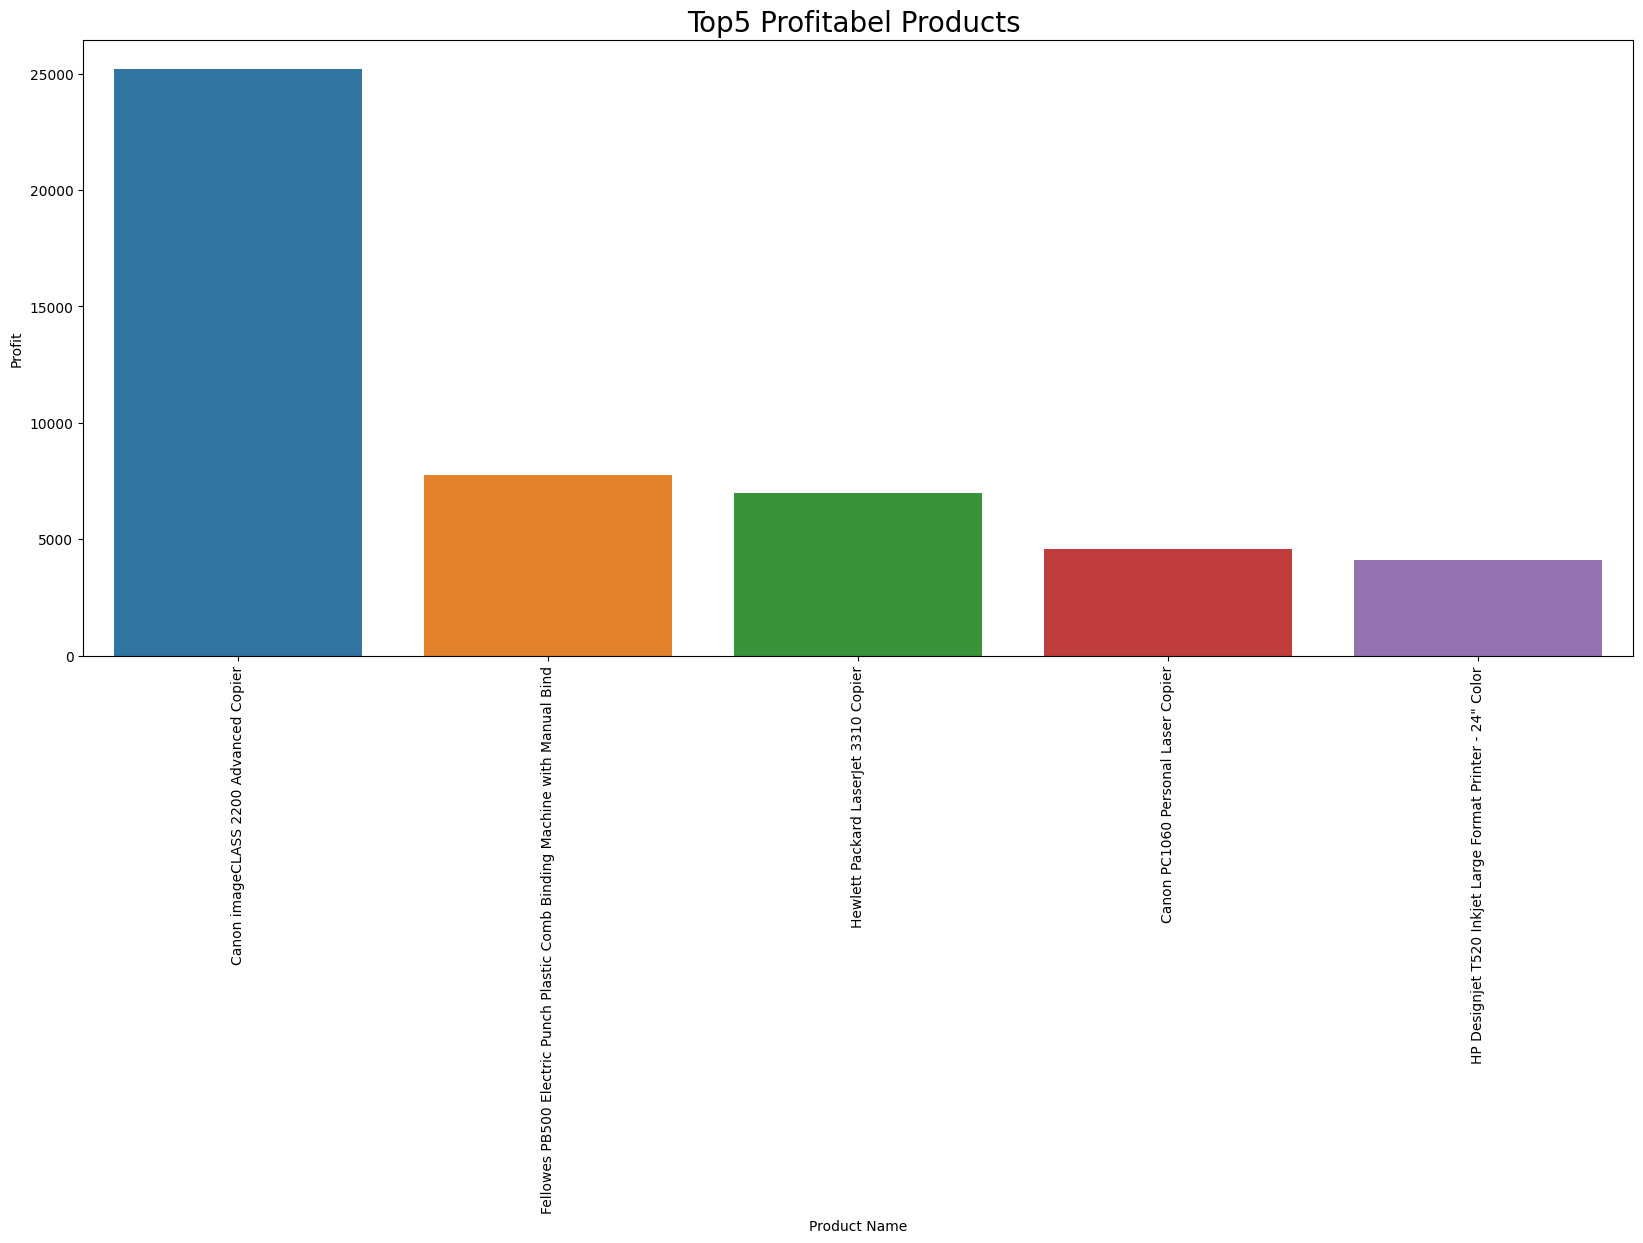

In [ ]:
plt.figure(figsize=(20,8))
sns.barplot(data=top_5_profit_products , x='Product Name' , y='Profit', hue='Product Name')

plt.xticks(rotation=90)
plt.title('Top5 Profitabel Products ',size=20)
plt.show()

In [ ]:
top5_selling_products.index

Index(['Canon imageCLASS 2200 Advanced Copier',
       'Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind',
       'Cisco TelePresence System EX90 Videoconferencing Unit',
       'HON 5400 Series Task Chairs for Big and Tall',
       'GBC DocuBind TL300 Electric Binding System'],
      dtype='object', name='Product Name')

In [ ]:
top5_selling_products.index == top_profit_products.index

array([ True,  True, False, False, False])

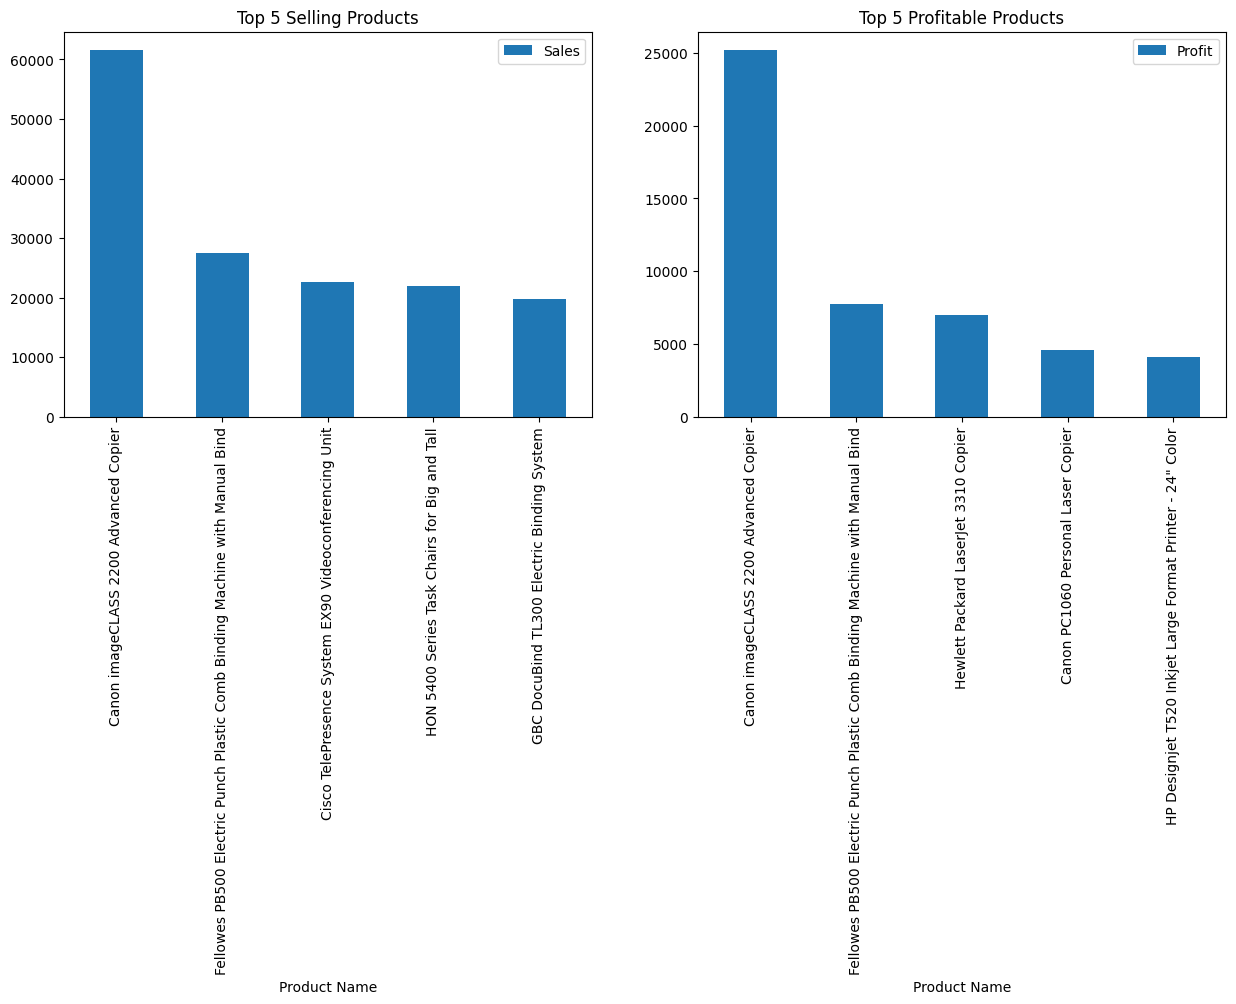

In [ ]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(15,5))


# Plot the top 5 selling products in the first column
top5_selling_products.plot(kind='bar', y='Sales', ax=ax1)
# Set the title for the first plot
ax1.set_title('Top 5 Selling Products')


# Plot the top 5 selling products in the first column
top_profit_products.plot(kind='bar', y='Profit', ax=ax2)
# Set the title for the first plot
ax2.set_title('Top 5 Profitable Products')


plt.show()

## 5. Analyse Détaillée des Produits Clés

Top 5 Selling Products:


Canon imageCLASS 2200 Advanced Copier


Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind



Cisco TelePresence System EX90 Videoconferencing Un


80
HON 5400 Series Task Chairs for Big and l

576
GBC DocuBind TL300 Electric Binding Sy6
.479


Top 5 Profit Products:


Canon imageCLASS 2200 Advanced Copier


Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind


Hewlett Packard LaserJet 3310 Copier


Canon PC1060 Personal Laser Copierr


HP Designjet T520 Inkjet Large Format Printer r 24" Color	4094.9766

The Highest Selling & Profitable Products:


- Canon imageCLASS 2200 Advanced Copier
- Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind

In [ ]:
data['Region'].value_counts()

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

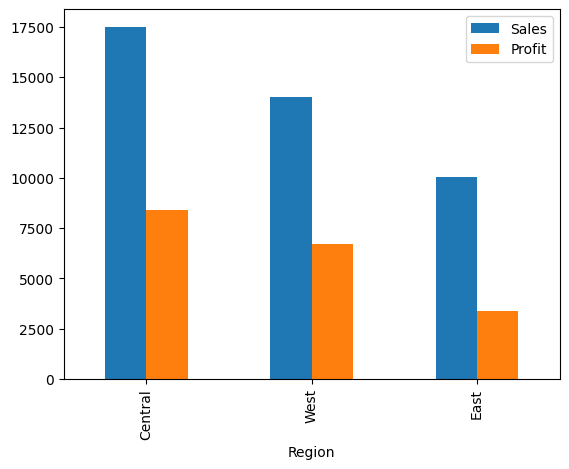

In [ ]:
# Filter the data to only include Canon imageCLASS 2200 Advanced Copie
product= data[data['Product Name'] == 'Canon imageCLASS 2200 Advanced Copier']

# Group data by the Region
region_group = product.groupby(['Region'])[['Sales','Profit']].mean().sort_values(by=['Sales','Profit'], ascending=False)

region_group.plot(kind='bar')
plt.show()

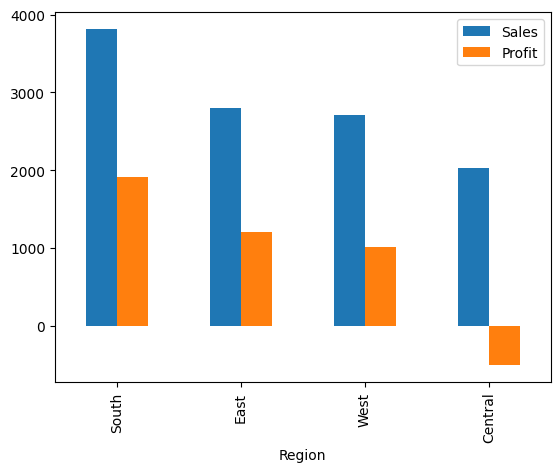

In [ ]:
# Filter the data to only include Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind
product= data[data['Product Name'] == 'Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind']

# Group data by the Region
region_group = product.groupby(['Region'])[['Sales','Profit']].mean().sort_values(by=['Sales','Profit'], ascending=False)

region_group.plot(kind='bar')
plt.show()

In [ ]:
product= data[(data['Product Name'] == 'Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind') & (data['Region'] =='Central')]
product


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Months
2846,2847,CA-2017-152093,9/10/2017,9/15/2017,Standard Class,SN-20560,Skye Norling,Home Office,United States,Chicago,...,OFF-BI-10003527,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,762.594,3,0.8,-1143.891,2017,9
5310,5311,CA-2017-131254,11/19/2017,11/21/2017,First Class,NC-18415,Nathan Cano,Consumer,United States,Houston,...,OFF-BI-10003527,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,6,0.8,-2287.782,2017,11
7683,7684,CA-2015-120782,4/28/2015,5/1/2015,First Class,SD-20485,Shirley Daniels,Home Office,United States,Midland,...,OFF-BI-10003527,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,3812.970,3,0.0,1906.485,2015,4


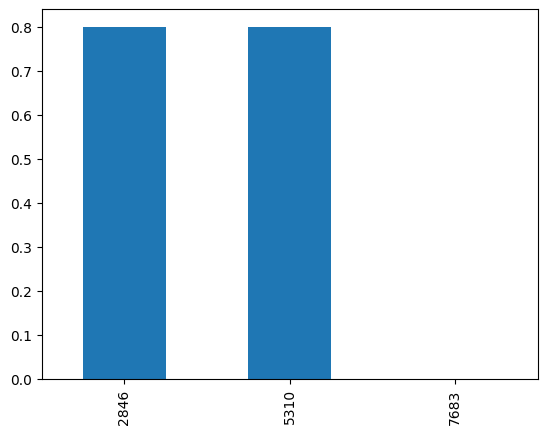

In [ ]:
product= data[(data['Product Name'] == 'Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind') & (data['Region'] =='Central')]
product['Discount'].plot(kind='bar')
plt.show()


The company loses when it sells its (Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind) products in the central region as it make 80% discount on 2 products from 3 products

## 6. Tendance des Ventes et des Profits par Année

In [ ]:
data['Year']= pd.to_datetime(data['Order Date']).dt.year
data['Year']

0       2016
1       2016
2       2016
3       2015
4       2015
        ... 
9989    2014
9990    2017
9991    2017
9992    2017
9993    2017
Name: Year, Length: 9994, dtype: int32

In [ ]:
SalesByYears= data.groupby('Year', as_index=False)[['Sales']].sum().sort_values(by='Sales', ascending=False)
SalesByYears

,Year,Sales
3,2017,733215.2552
2,2016,609205.5980
0,2014,484247.4981
1,2015,470532.5090


In [ ]:
ProfitByYears= data.groupby('Year', as_index=False)[['Profit']].sum().sort_values(by='Profit', ascending=False)
ProfitByYears

,Year,Profit
3,2017,93439.2696
2,2016,81795.1743
1,2015,61618.6037
0,2014,49543.9741


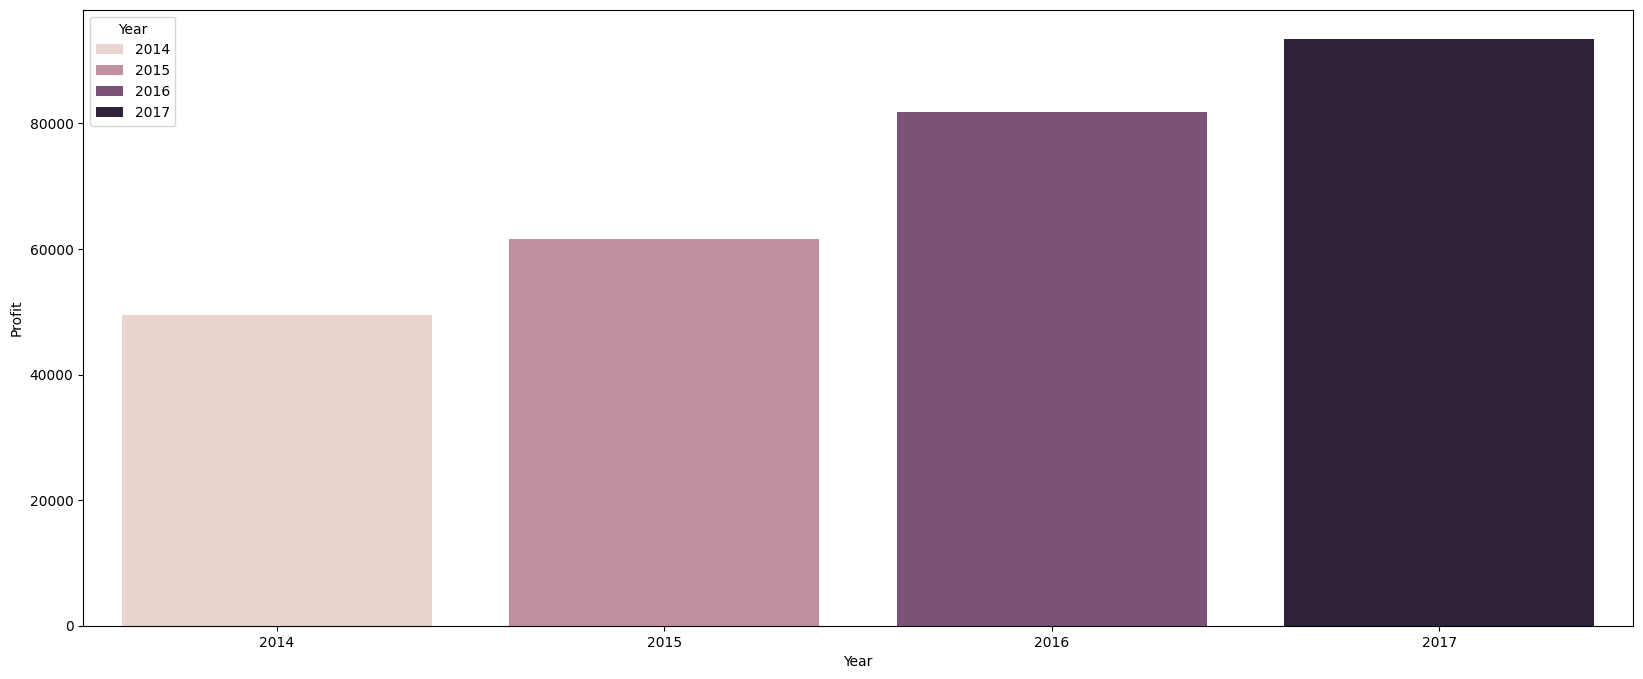

In [ ]:
plt.figure(figsize=(20,8))
sns.barplot(data=ProfitByYears, x='Year', y='Profit', hue='Year')
plt.show()

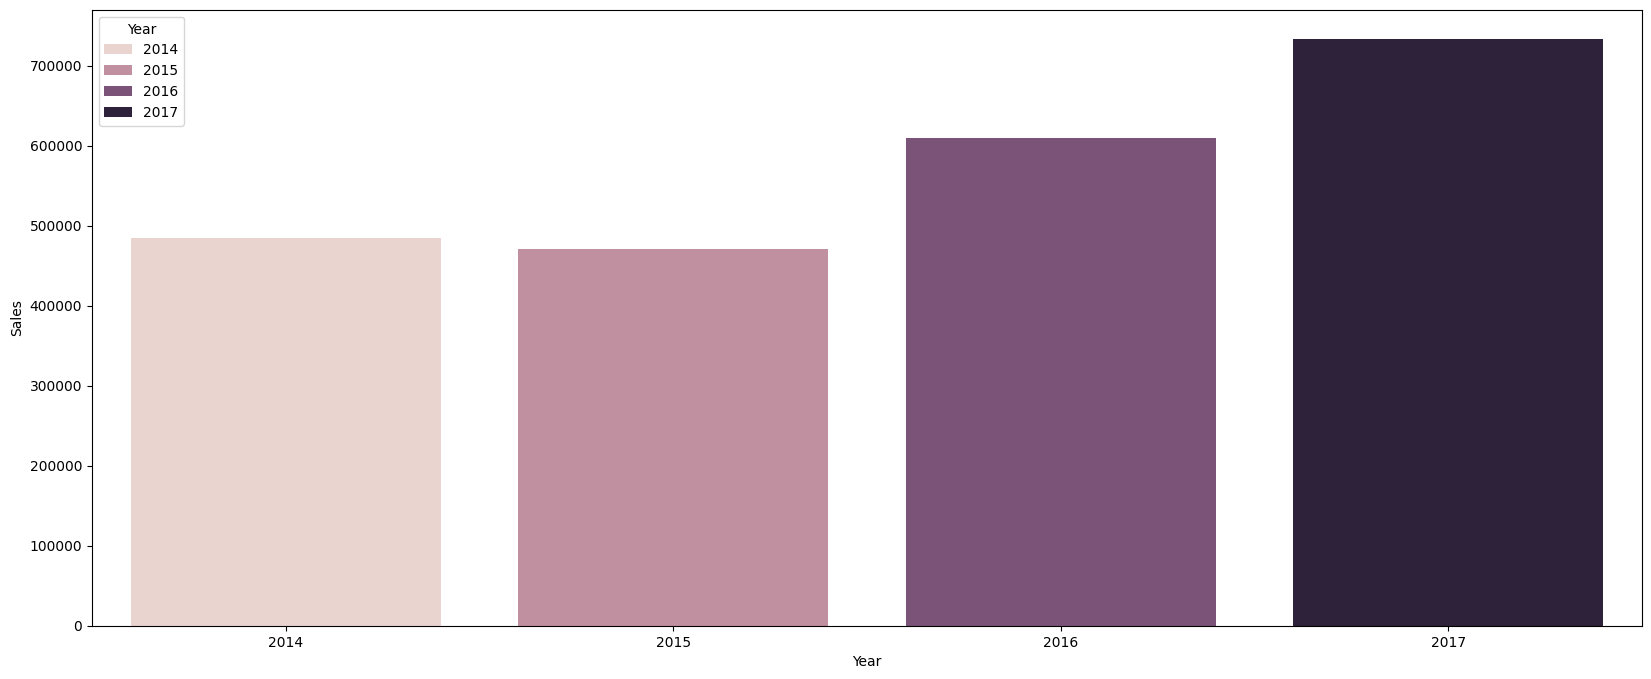

In [ ]:
plt.figure(figsize=(20,8))
sns.barplot(data=SalesByYears, x='Year', y='Sales', hue='Year')
plt.show()

## 7. Analyse Géographique (Régions, Villes, États)

According to the above graph the sales & profit have been reach to the peak in 2017

Which region & Place generates the most sales & Profit?

In [ ]:
df_places=data[['Country','City','State','Region']]
df_places

,Country,City,State,Region
0,United States,Henderson,Kentucky,South
1,United States,Henderson,Kentucky,South
2,United States,Los Angeles,California,West
3,United States,Fort Lauderdale,Florida,South
4,United States,Fort Lauderdale,Florida,South
...,...,...,...,...
9989,United States,Miami,Florida,South
9990,United States,Costa Mesa,California,West
9991,United States,Costa Mesa,California,West
9992,United States,Costa Mesa,California,West


In [ ]:
for i in df_places:
    print(i, ':', df_places[i].nunique())

Country : 1
City : 531
State : 49
Region : 4


In [ ]:
df_places=data[['City','State','Region']]
df_places

,City,State,Region
0,Henderson,Kentucky,South
1,Henderson,Kentucky,South
2,Los Angeles,California,West
3,Fort Lauderdale,Florida,South
4,Fort Lauderdale,Florida,South
...,...,...,...
9989,Miami,Florida,South
9990,Costa Mesa,California,West
9991,Costa Mesa,California,West
9992,Costa Mesa,California,West


In [ ]:
df_places=data[['Country','City','State','Region','Sales','Profit']]
df_places

,Country,City,State,Region,Sales,Profit
0,United States,Henderson,Kentucky,South,261.9600,41.9136
1,United States,Henderson,Kentucky,South,731.9400,219.5820
2,United States,Los Angeles,California,West,14.6200,6.8714
3,United States,Fort Lauderdale,Florida,South,957.5775,-383.0310
4,United States,Fort Lauderdale,Florida,South,22.3680,2.5164
...,...,...,...,...,...,...
9989,United States,Miami,Florida,South,25.2480,4.1028
9990,United States,Costa Mesa,California,West,91.9600,15.6332
9991,United States,Costa Mesa,California,West,258.5760,19.3932
9992,United States,Costa Mesa,California,West,29.6000,13.3200


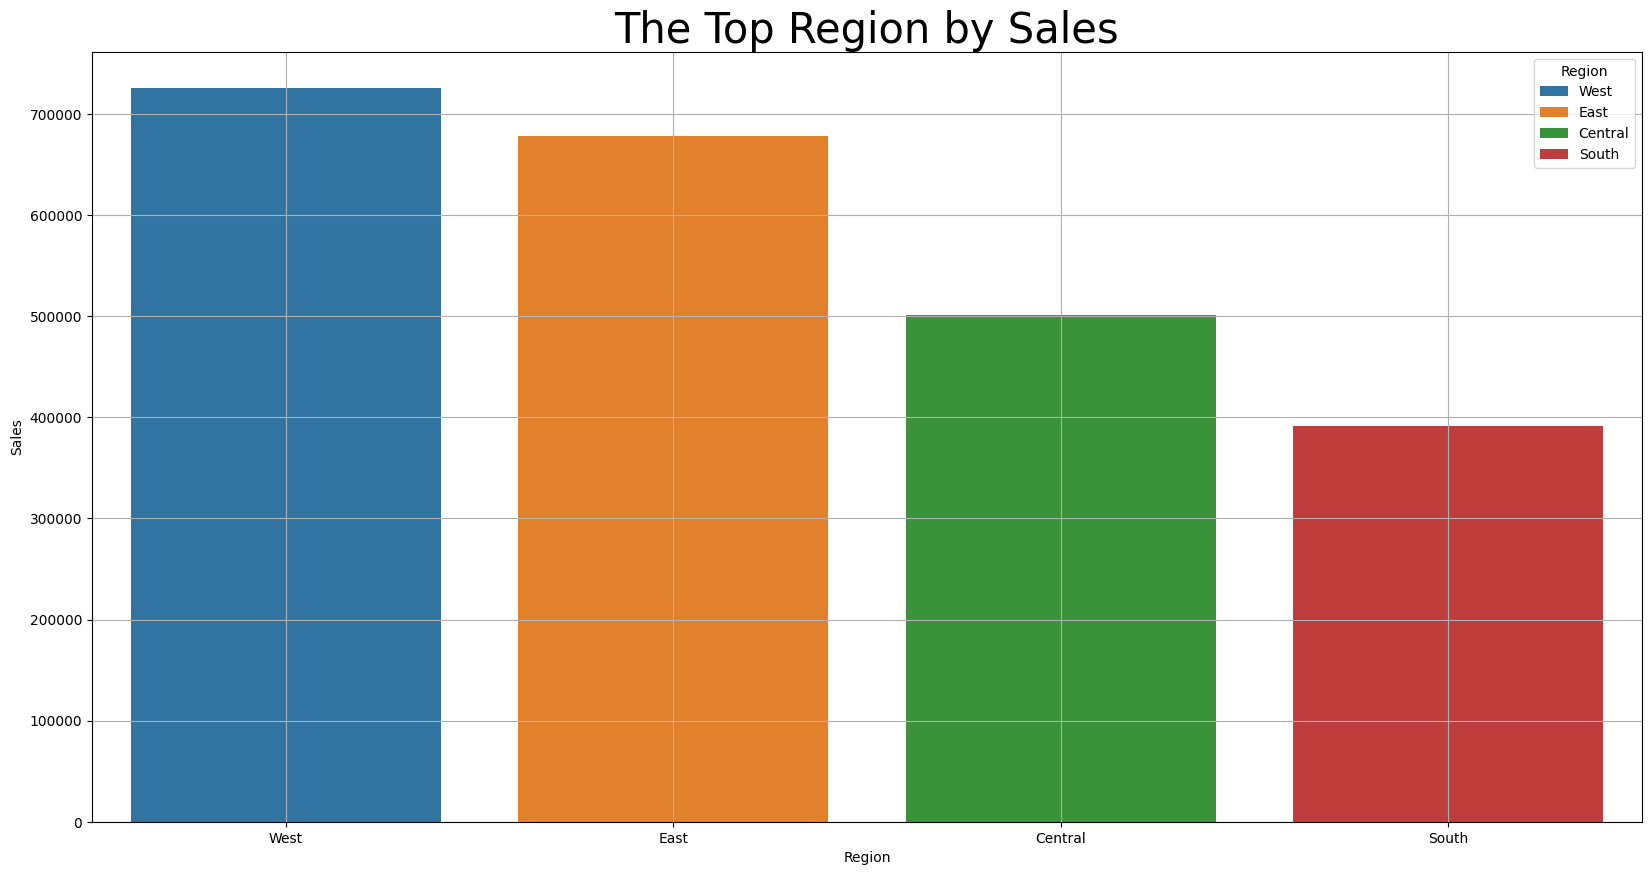

In [ ]:
# Which regions generate the most sales?
grouped_by_region_sales=df_places.groupby(['Region'],as_index=False)[['Sales']].sum().sort_values(by='Sales' , ascending=False)

plt.figure(figsize=(20,10))
sns.barplot(data=grouped_by_region_sales, x='Region', y='Sales',hue='Region',legend=True)

plt.title('The Top Region by Sales', size=30)

plt.grid()
plt.show()

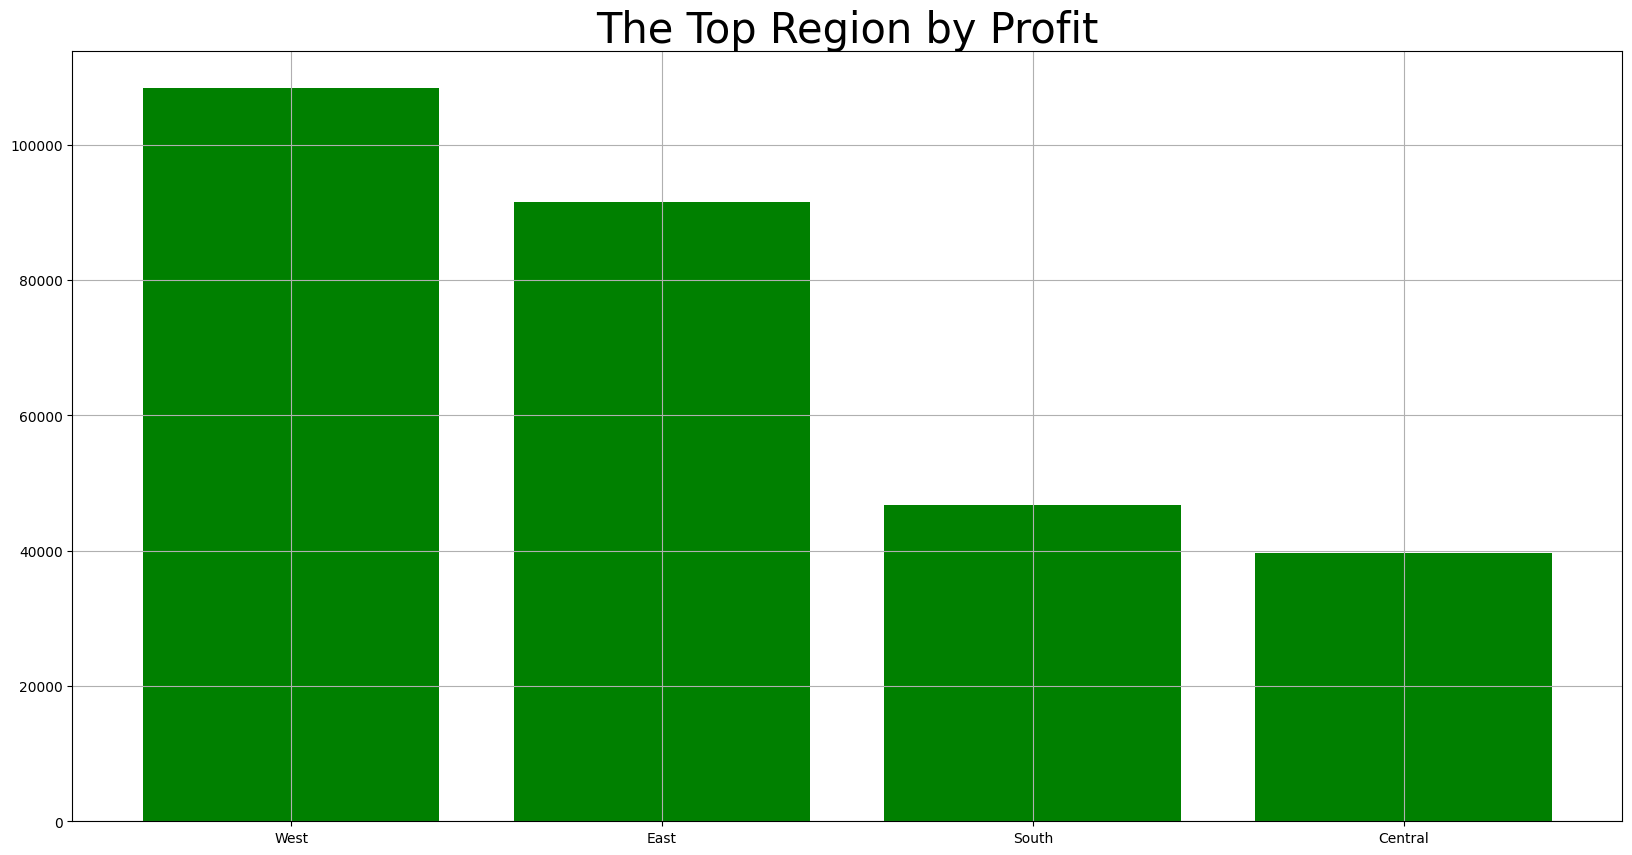

In [ ]:
#which regions generate the most Profit?
grouped_by_region_profit = df_places.groupby(['Region'],as_index=False)[['Profit']].sum().sort_values(by='Profit' , ascending= False)

plt.figure(figsize=(20,10))
plt.bar(grouped_by_region_profit['Region'], grouped_by_region_profit['Profit'],color='g')
plt.xlabel='Region'
plt.ylabel='Profit'

plt.title('The Top Region by Profit', size=30)
plt.grid()
plt.show()

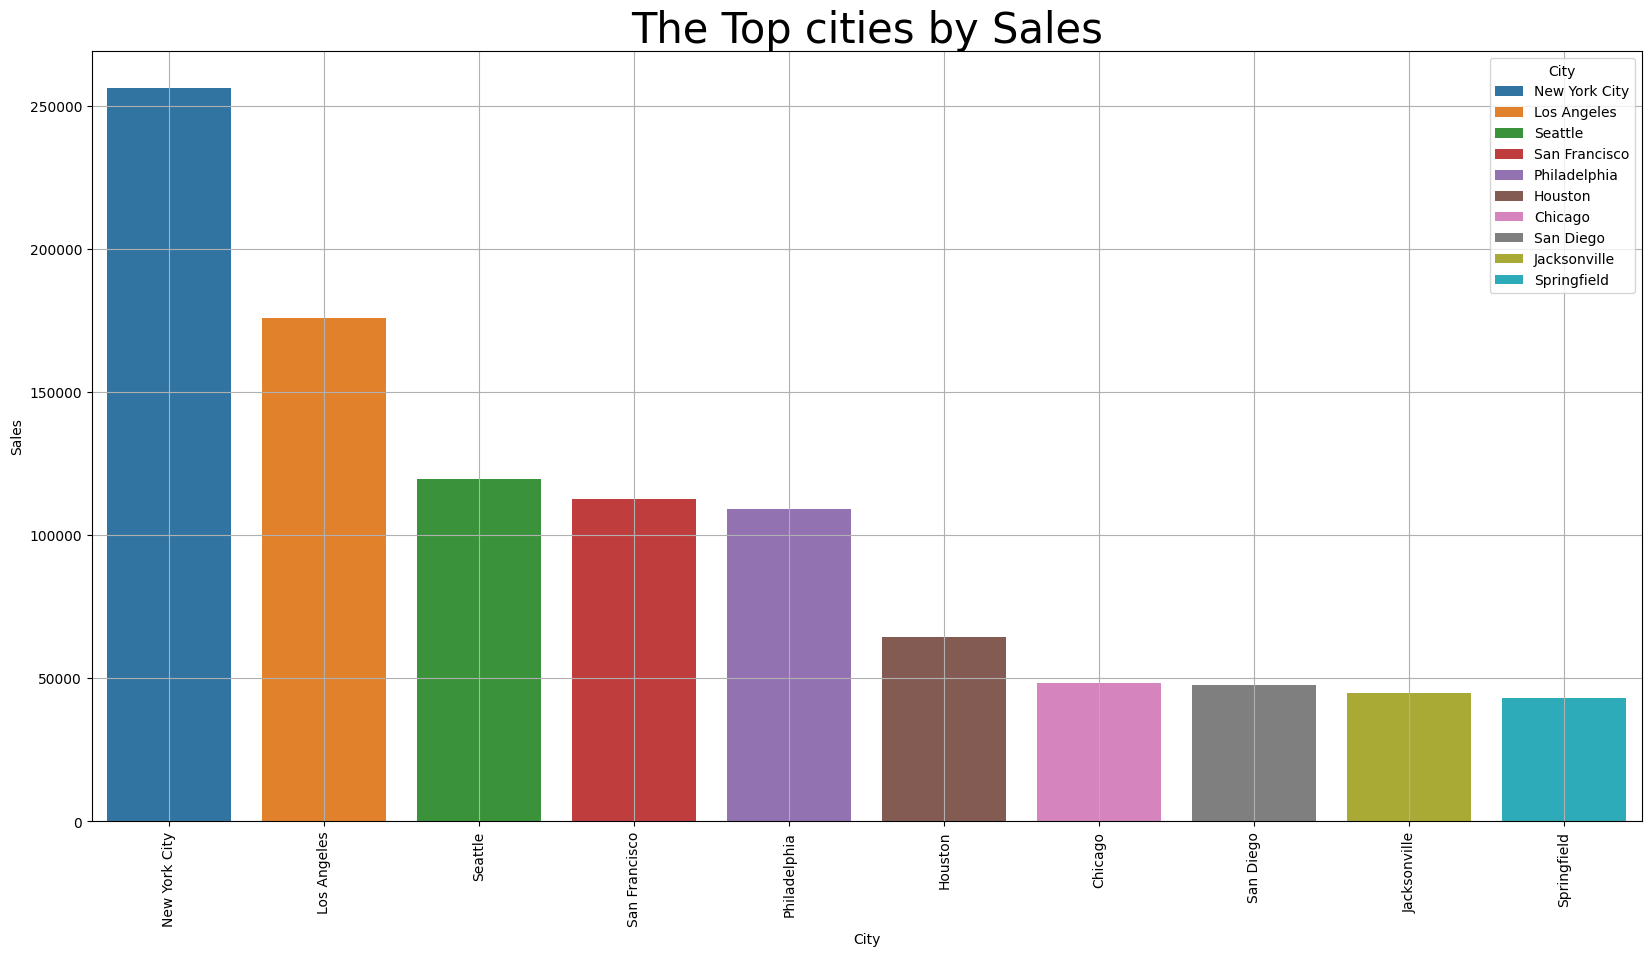

In [ ]:
# Which cities generate the most sales?

grouped_by_city_sales=df_places.groupby(['City'],as_index=False)['Sales'].sum().sort_values(by='Sales' , ascending=False)[:10]

plt.figure(figsize=(20,10))
sns.barplot(data=grouped_by_city_sales, x='City', y='Sales',hue='City',legend=True)
plt.xticks(rotation=90)
plt.title('The Top cities by Sales', size=30)

plt.grid()
plt.show()

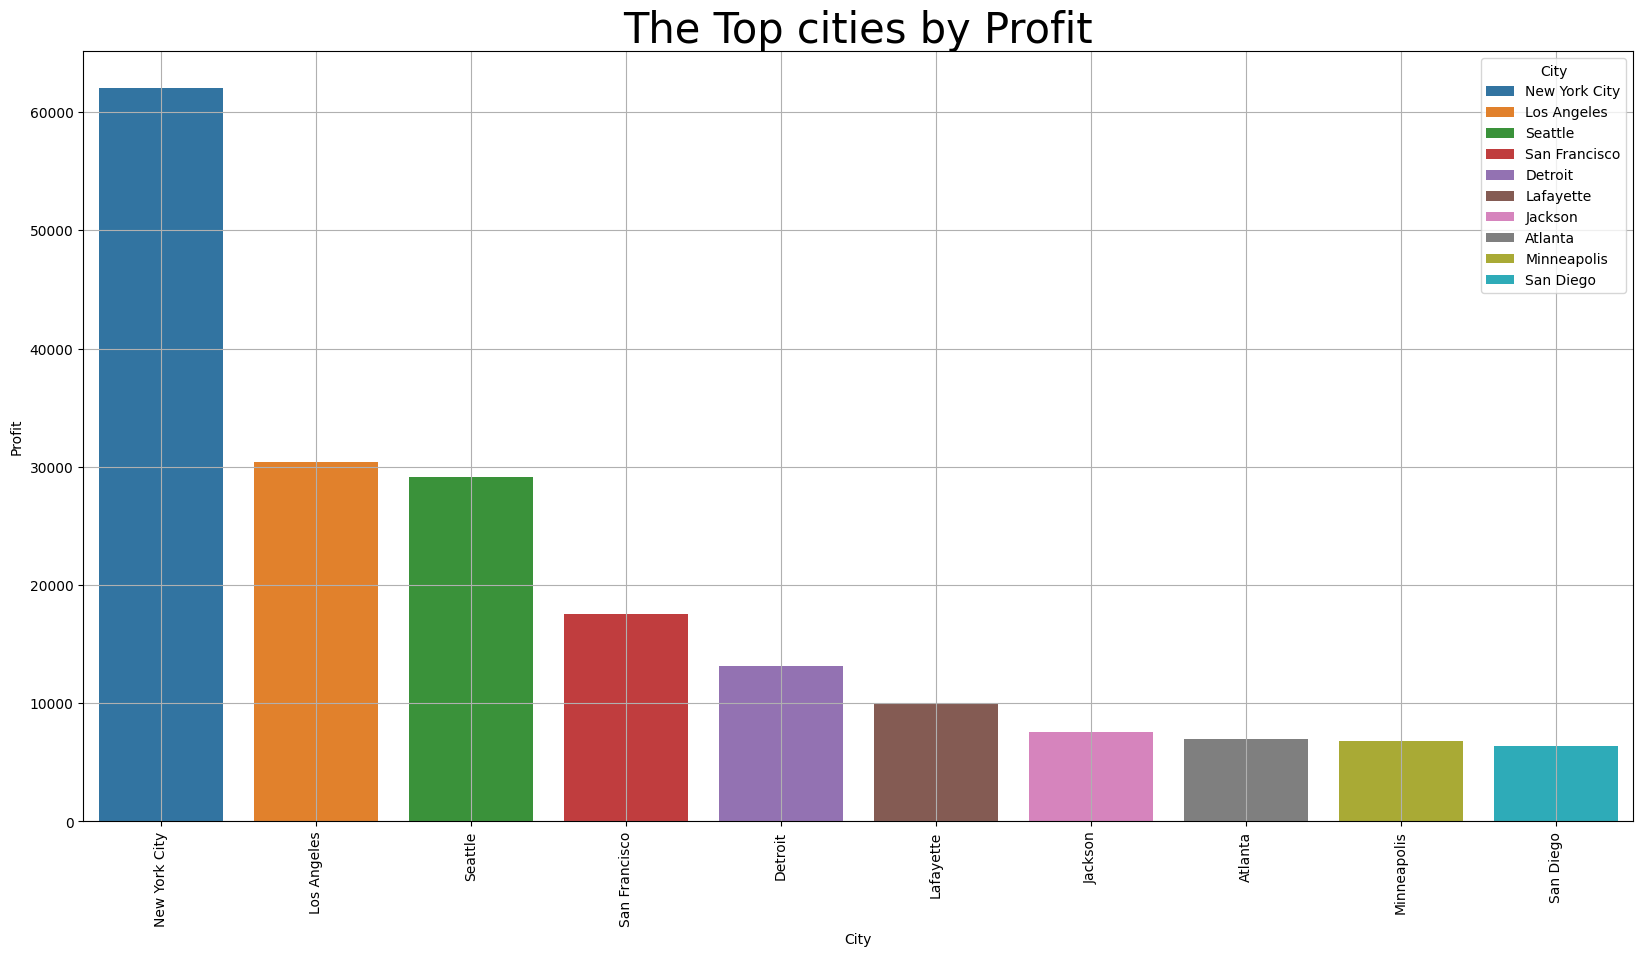

In [ ]:
# Which citites generate the most profit?
grouped_by_city_profit=df_places.groupby(['City'],as_index=False)[['Profit']].sum().sort_values(by='Profit', ascending=False)[:10]


plt.figure(figsize=(20,10))
sns.barplot(data=grouped_by_city_profit, x='City', y='Profit',hue='City',legend=True)
plt.xticks(rotation=90)
plt.title('The Top cities by Profit', size=30)

plt.grid()
plt.show()

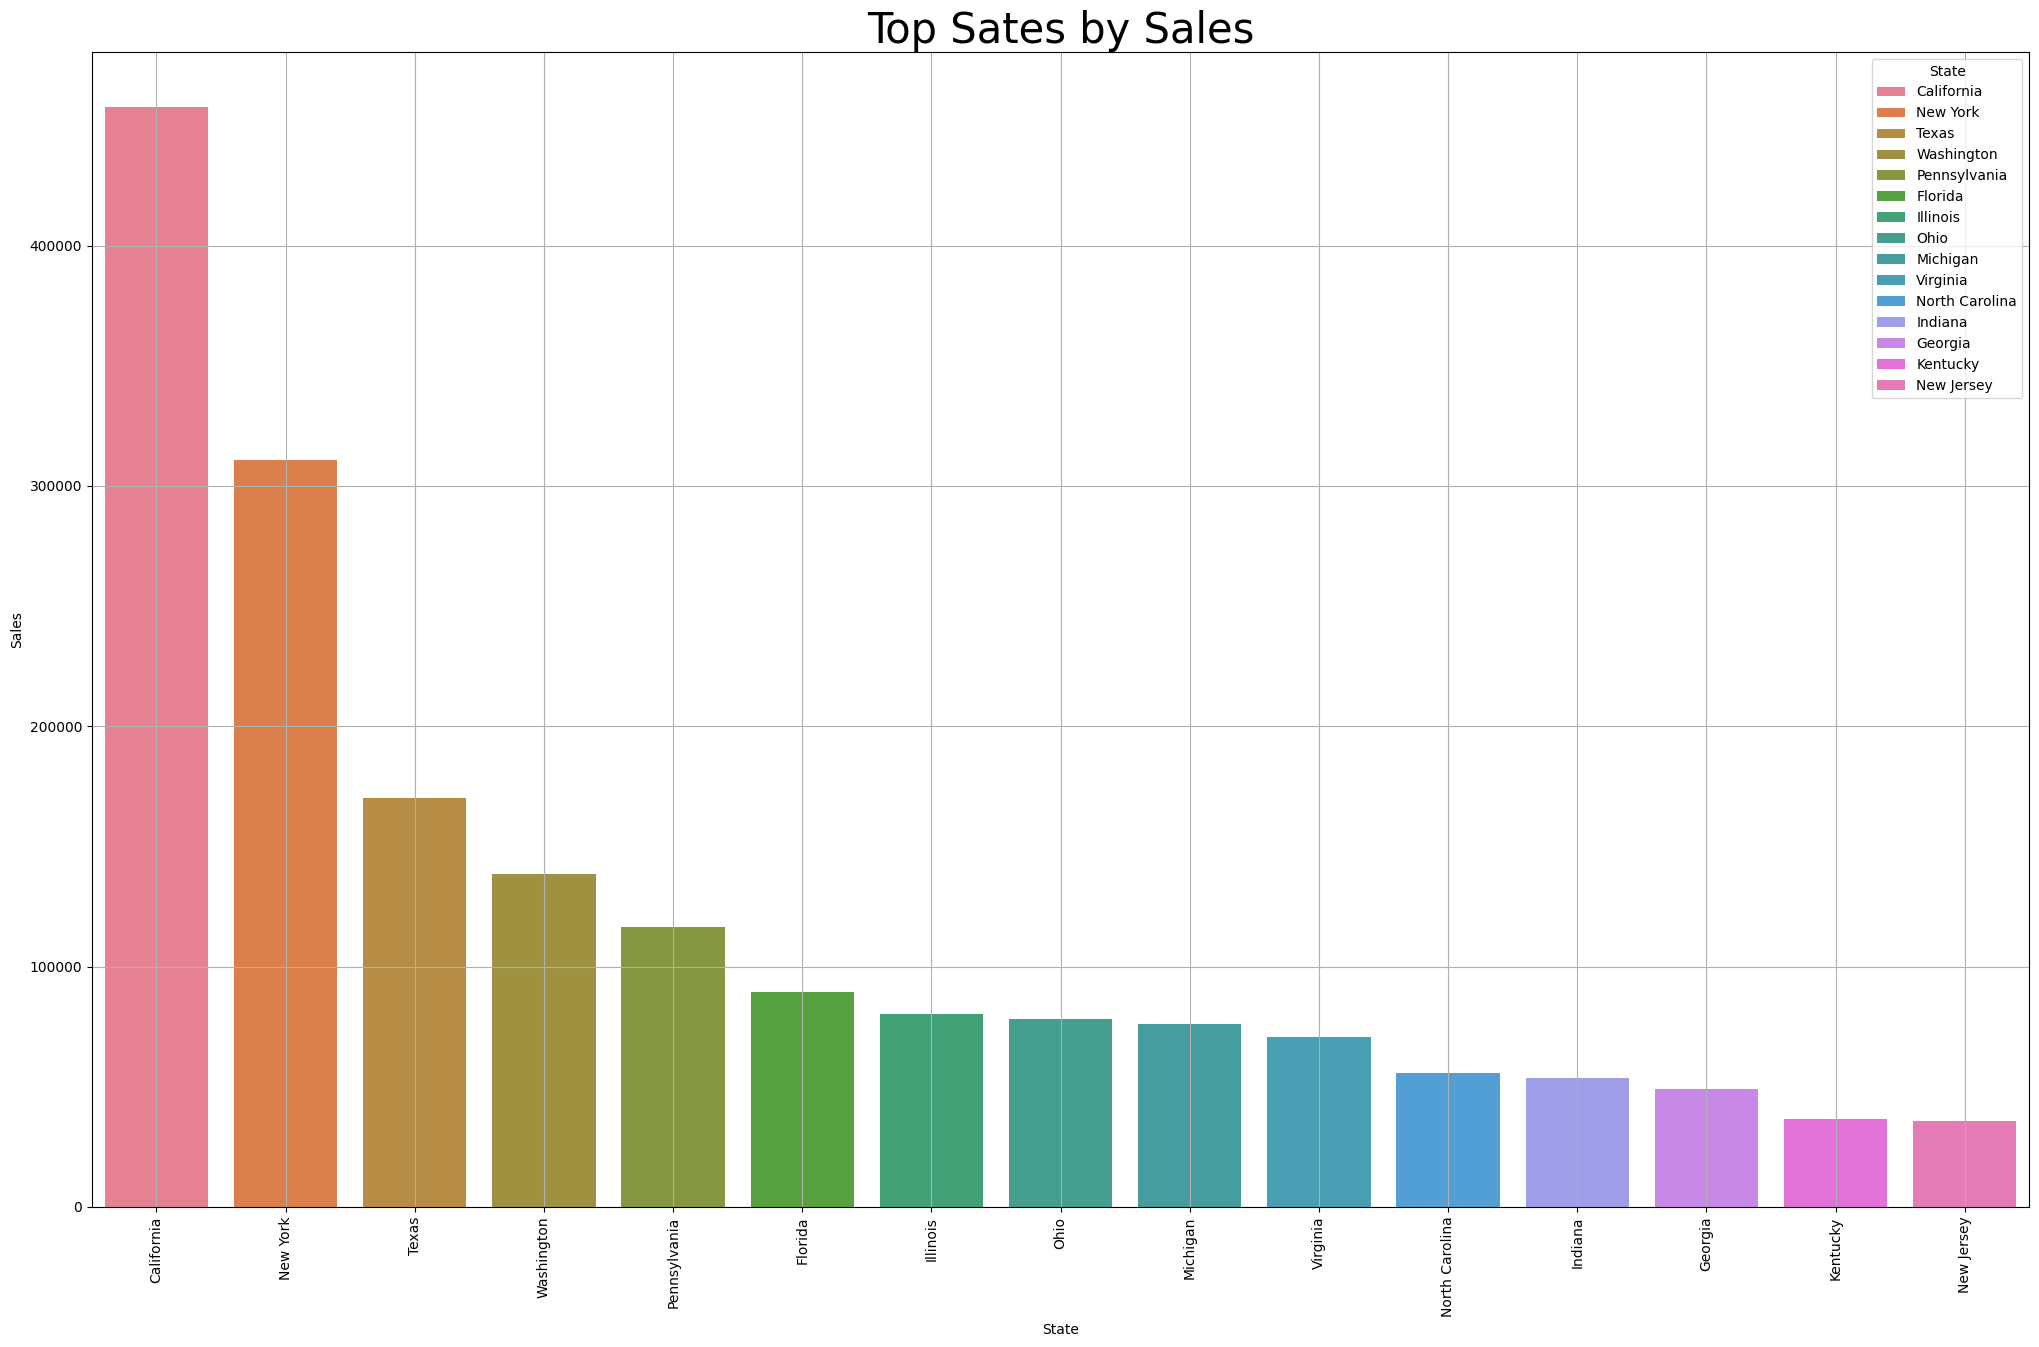

In [ ]:
# Which States generate the most Sales?
grouped_by_state_sales=df_places.groupby(['State'],as_index=False)[['Sales']].sum().sort_values(by='Sales' , ascending=False)[:15]

plt.figure(figsize=(25,15))
sns.barplot(data=grouped_by_state_sales, x='State', y='Sales',hue='State',legend=True)
plt.xticks(rotation=90)
plt.title('Top Sates by Sales', size=30)
plt.grid()
plt.show()

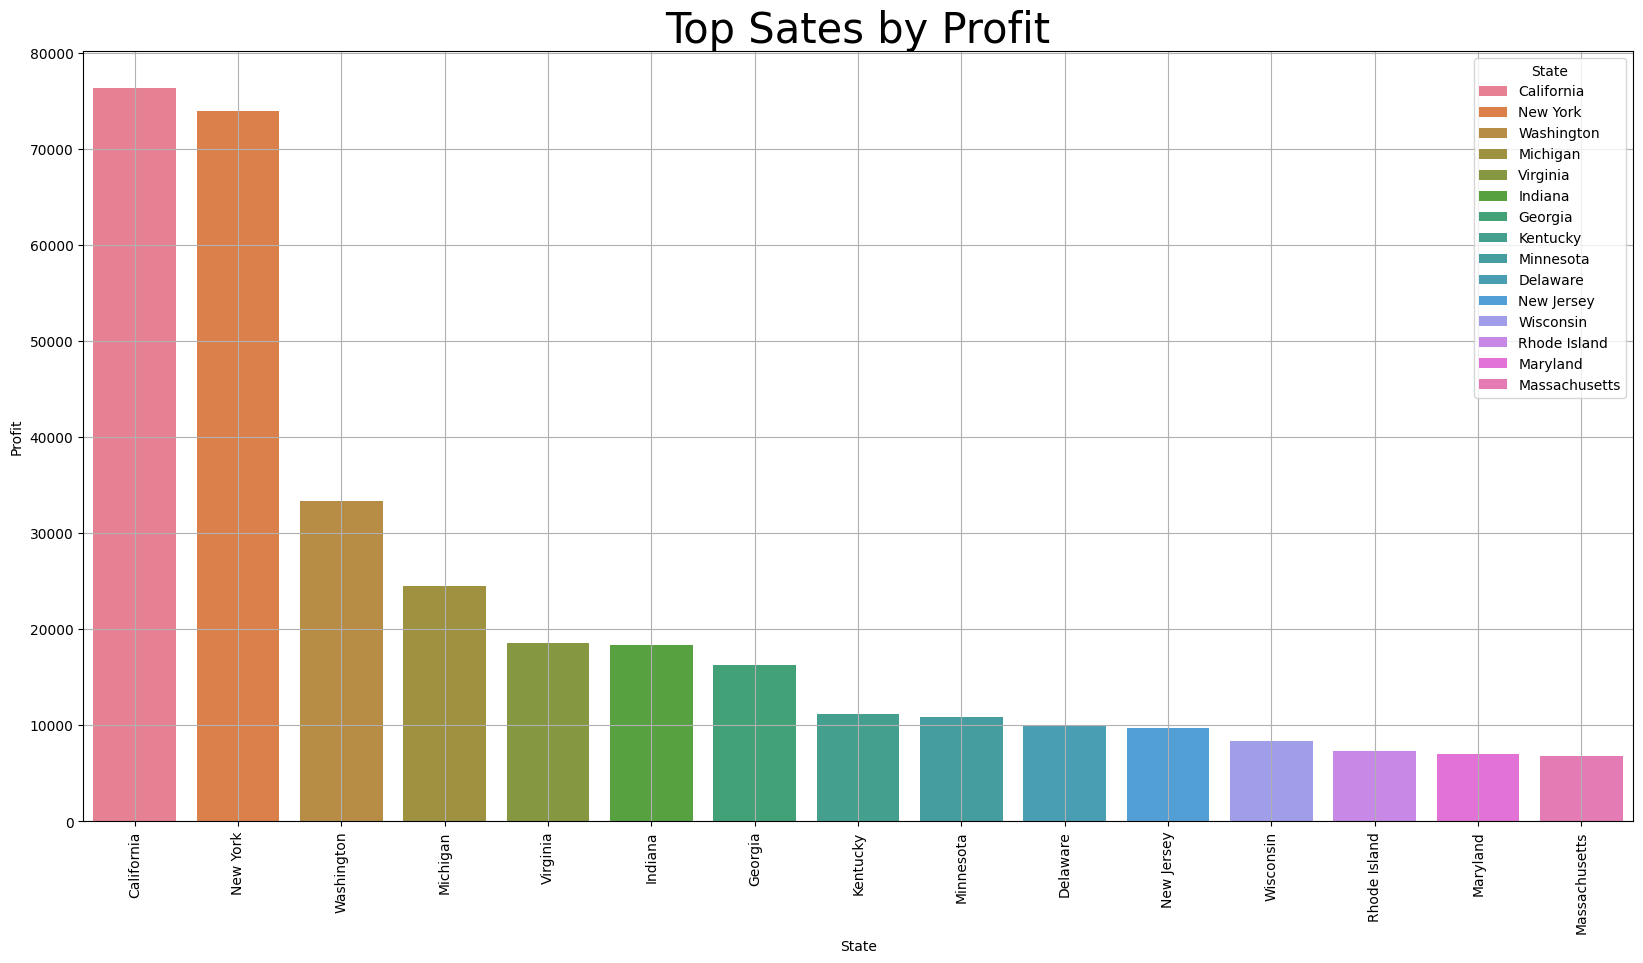

In [ ]:
grouped_by_state_Profit=df_places.groupby(['State'],as_index=False)[['Profit']].sum().sort_values(by='Profit' , ascending=False)[:15]

plt.figure(figsize=(20,10))

sns.barplot(data=grouped_by_state_Profit, x='State', y='Profit',hue='State',legend=True)
plt.xticks(rotation=90)
plt.title('Top Sates by Profit', size=30)
plt.grid()
plt.show()

## 8. Impact de la Remise sur les Ventes et les Profits

Top Placies are:


Cities: New York, Los Angeles, Seattle, San Francisisco, Philadelphia


State: California,New York


Region: West

--------------------------------------------------------------------------

What is the impact of the discont on sales ?

In [ ]:
data['Discount'].value_counts()

Discount
0.00    4798
0.20    3657
0.70     418
0.80     300
0.30     227
0.40     206
0.60     138
0.10      94
0.50      66
0.15      52
0.32      27
0.45      11
Name: count, dtype: int64

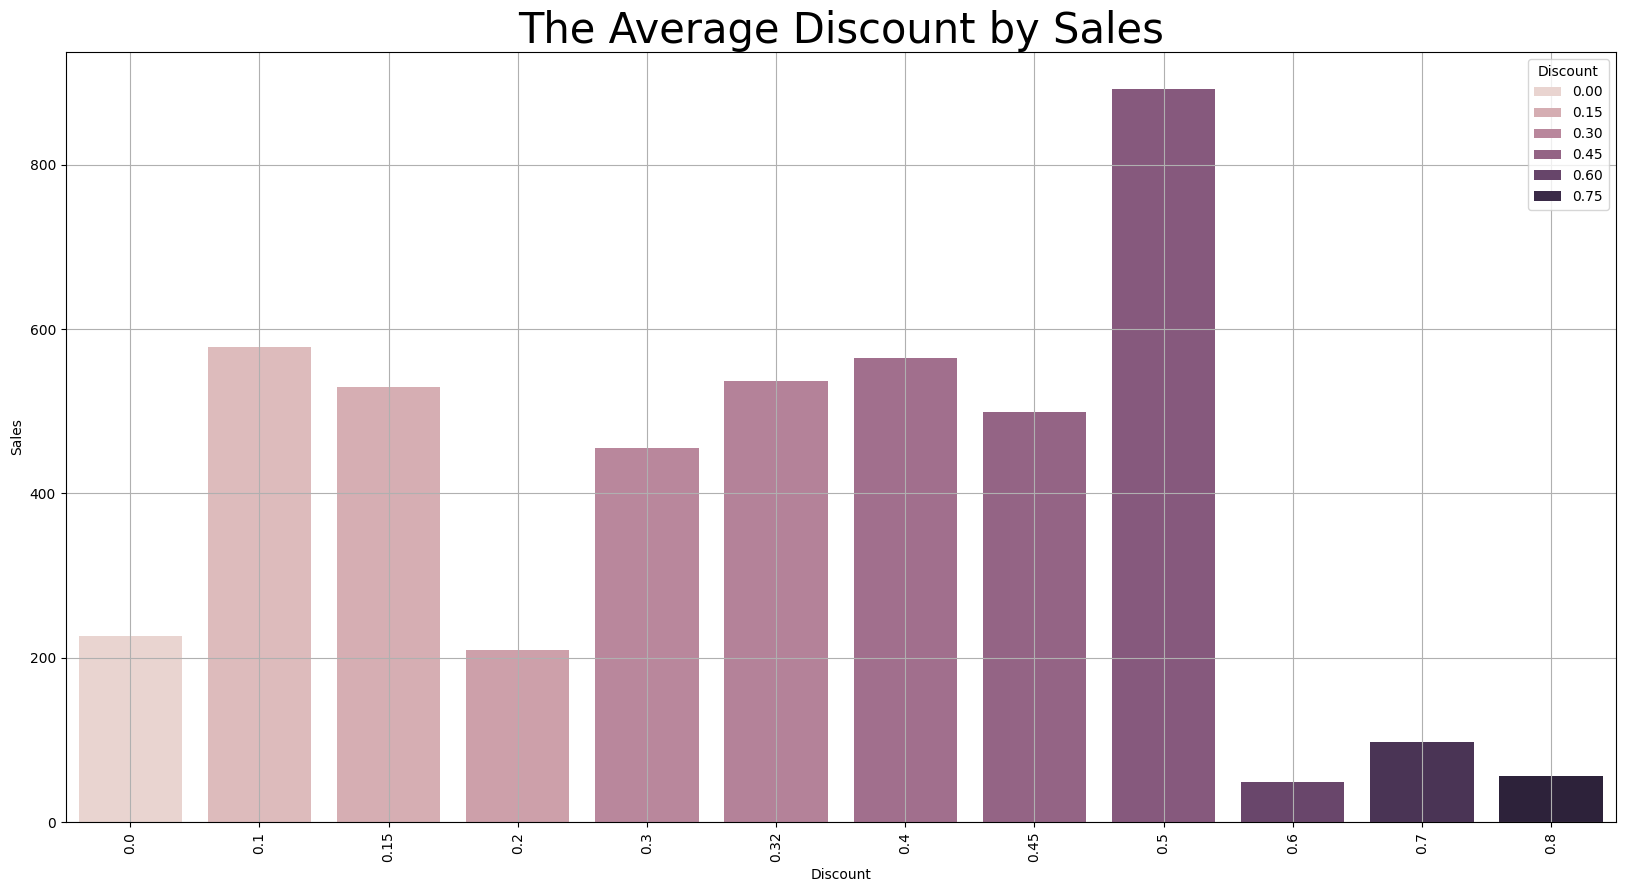

In [ ]:
discount_group=data.groupby(['Discount'],as_index=False)['Sales'].mean().sort_values(by='Sales' ,ascending=False)

plt.figure(figsize=(20,10))

sns.barplot(data=discount_group, x='Discount', y='Sales',hue='Discount',legend=True)
plt.xticks(rotation=90)
plt.title('The Average Discount by Sales', size=30)
plt.grid()
plt.show()

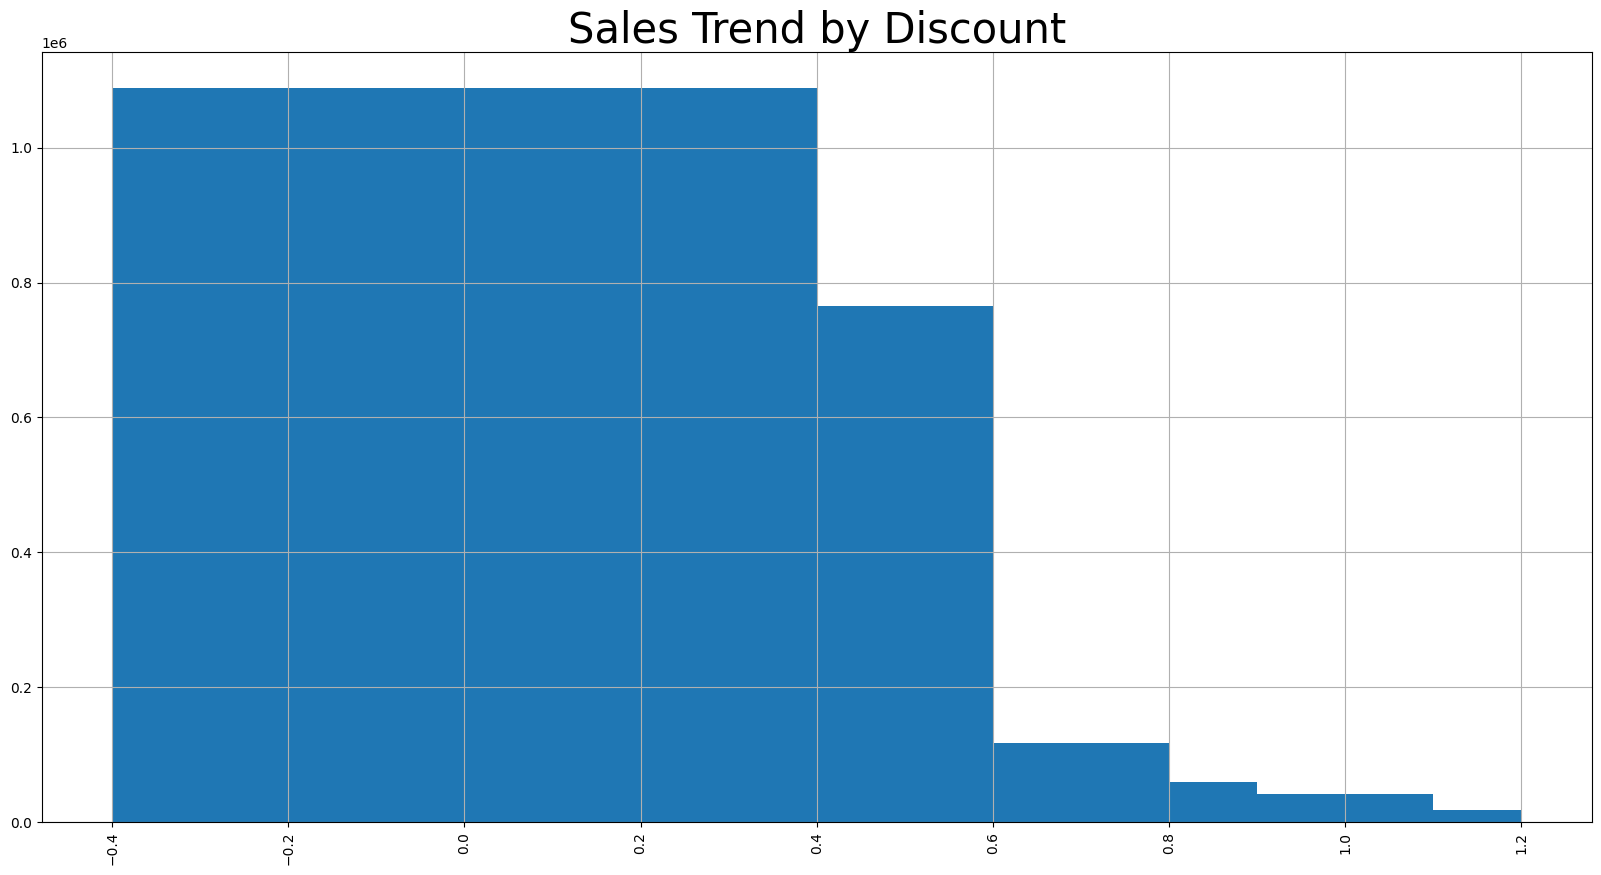

In [ ]:
discount_group_by_sales=data.groupby(['Discount'],as_index=False)['Sales'].sum().sort_values(by='Sales', ascending=False)
plt.figure(figsize=(20,10))

plt.bar(discount_group_by_sales['Discount'], discount_group_by_sales['Sales'],linewidth=30)

plt.xlabel='Discount'
plt.ylabel='Sales'

plt.xticks(rotation=90)
plt.title('Sales Trend by Discount', size=30)
plt.grid()
plt.show()




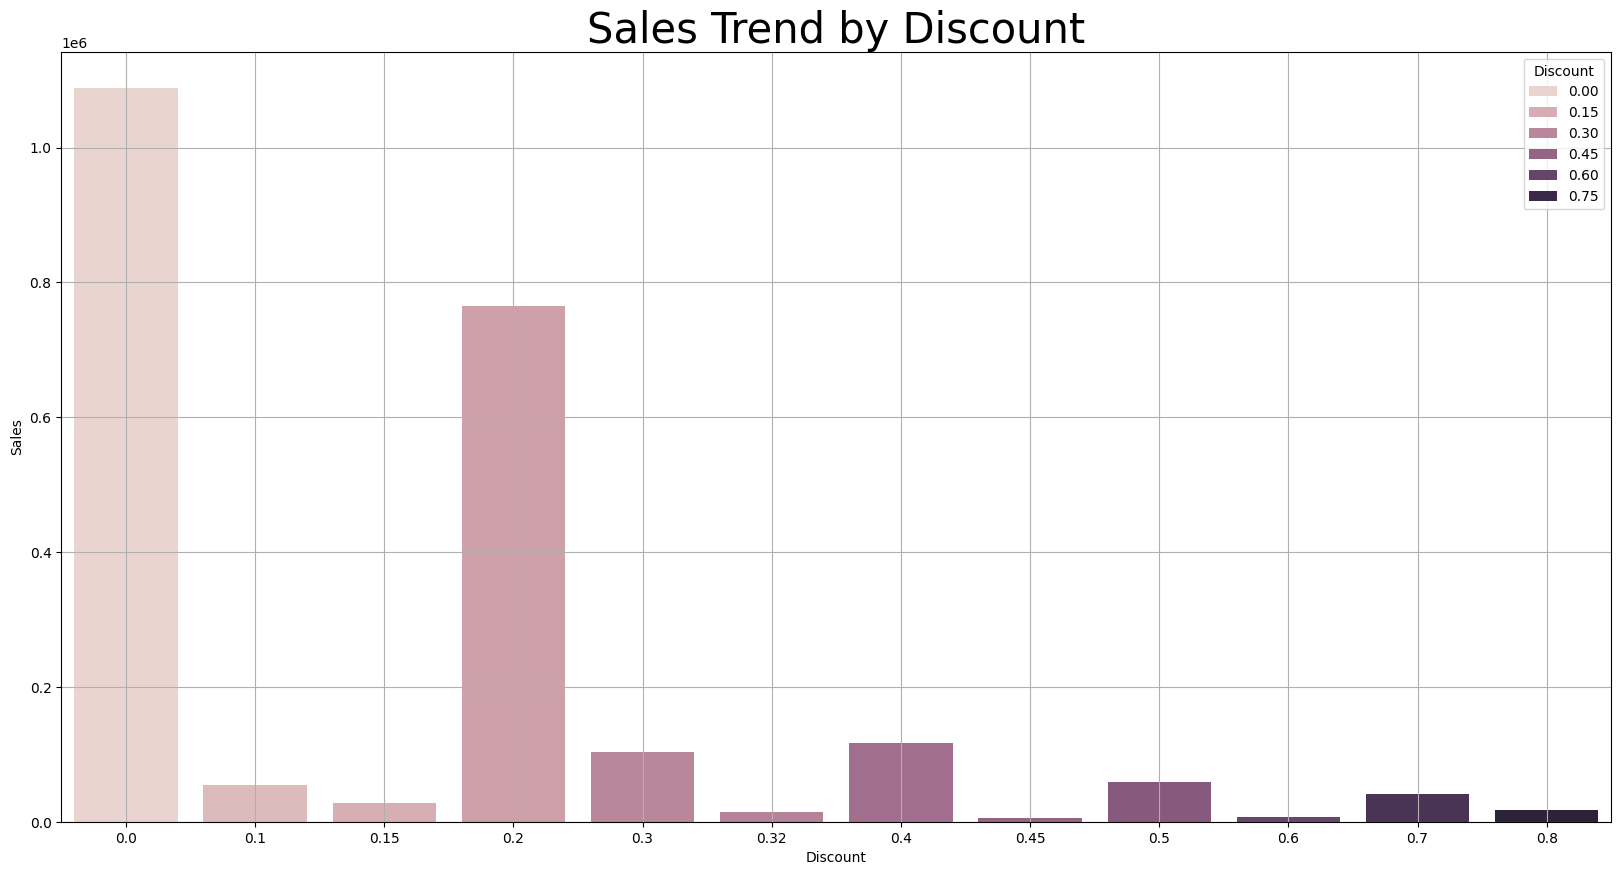

In [ ]:
discount_group_by_sales=data.groupby(['Discount'],as_index=False)['Sales'].sum().sort_values(by='Sales', ascending=False)

plt.figure(figsize=(20,10))

sns.barplot(data=discount_group_by_sales, x='Discount', y='Sales',hue='Discount',legend=True)
plt.title('Sales Trend by Discount', size=30)
plt.grid()
plt.show()

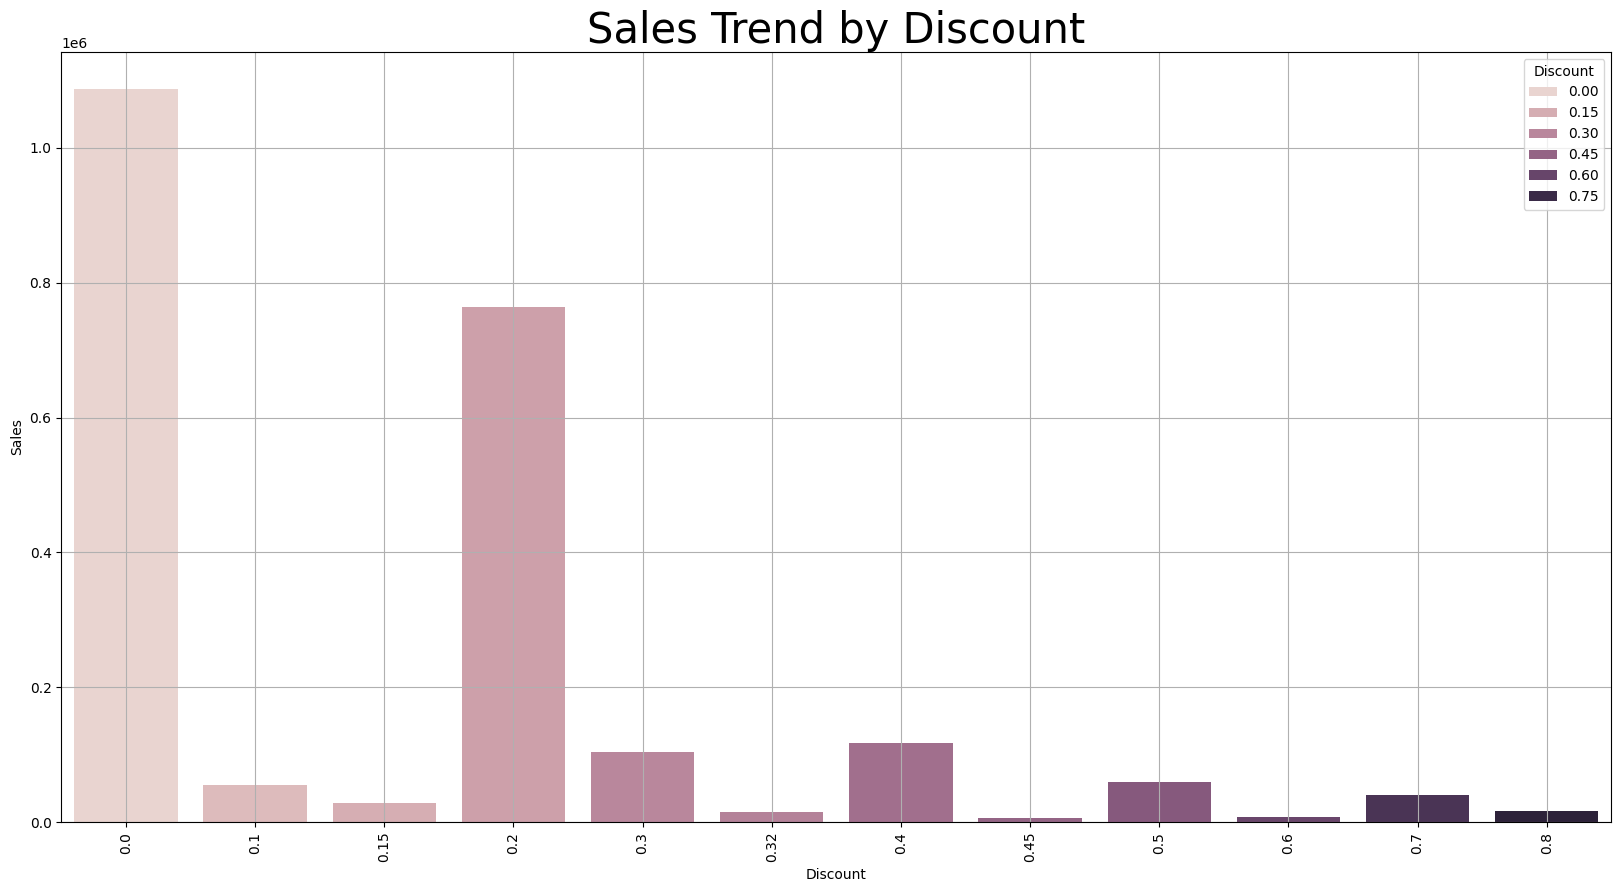

In [ ]:
discount_group_by_sales=data.groupby(['Discount'],as_index=False)['Sales'].sum()

plt.figure(figsize=(20,10))

sns.barplot(data=discount_group_by_sales, x='Discount', y='Sales',hue='Discount',legend=True)
plt.xticks(rotation=90)
plt.title('Sales Trend by Discount', size=30)
plt.grid()
plt.show()

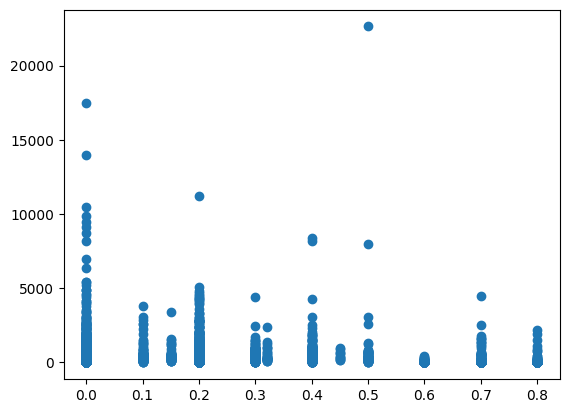

In [ ]:
# Scatter between Sales and Discount
plt.scatter(data['Discount'], data['Sales'])
plt.xlabel='Discount'
plt.ylabel='Sales'
plt.show()

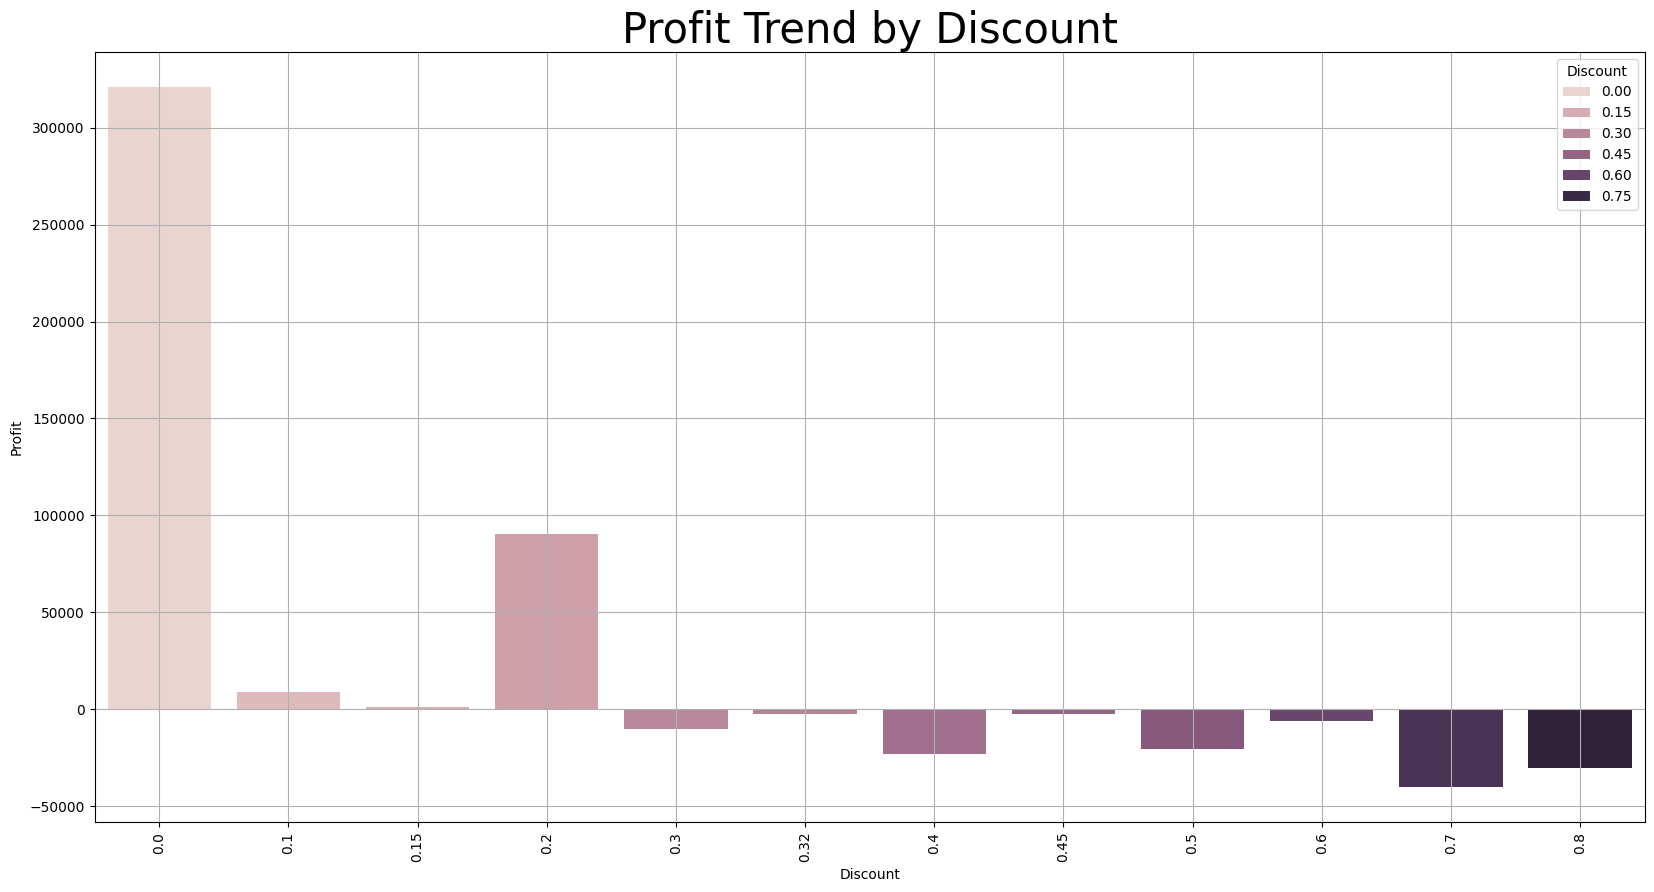

In [ ]:
discount_group_by_profit=data.groupby(['Discount'],as_index=False)['Profit'].sum().sort_values(by='Profit' ,ascending=False)

plt.figure(figsize=(20,10))

sns.barplot(data=discount_group_by_profit, x='Discount', y='Profit',hue='Discount',legend=True)
plt.xticks(rotation=90)
plt.title('Profit Trend by Discount', size=30)
plt.grid()
plt.show()

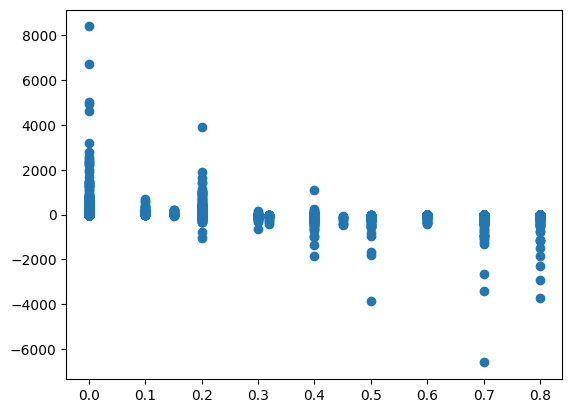

In [ ]:
# Scatter between Profit and Discount
plt.scatter(data['Discount'], data['Profit'])
plt.xlabel='Discount'
plt.ylabel='Profit'
plt.show()

## 9. Marge Bénéficiaire par Catégorie de Produit

The Best Sales are when the discount is 50%, but this leads to loss & non-profitability.


The discount 20% is the best solution, as they are the second and third best sellers & make profit

-----------------------------------------------------------------

In [ ]:
# The Total average profit for each category
profit_by_category= data.groupby(['Category'], as_index=False)['Profit'].sum().sort_values(by='Profit', ascending=False)
profit_by_category

,Category,Profit
2,Technology,145454.9481
1,Office Supplies,122490.8008
0,Furniture,18451.2728


In [ ]:
# The average profit for each category
avg_profit_margin_by_category= data.groupby(['Category'], as_index=False)['Profit'].mean()
avg_profit_margin_by_category

,Category,Profit
0,Furniture,8.699327
1,Office Supplies,20.327050
2,Technology,78.752002


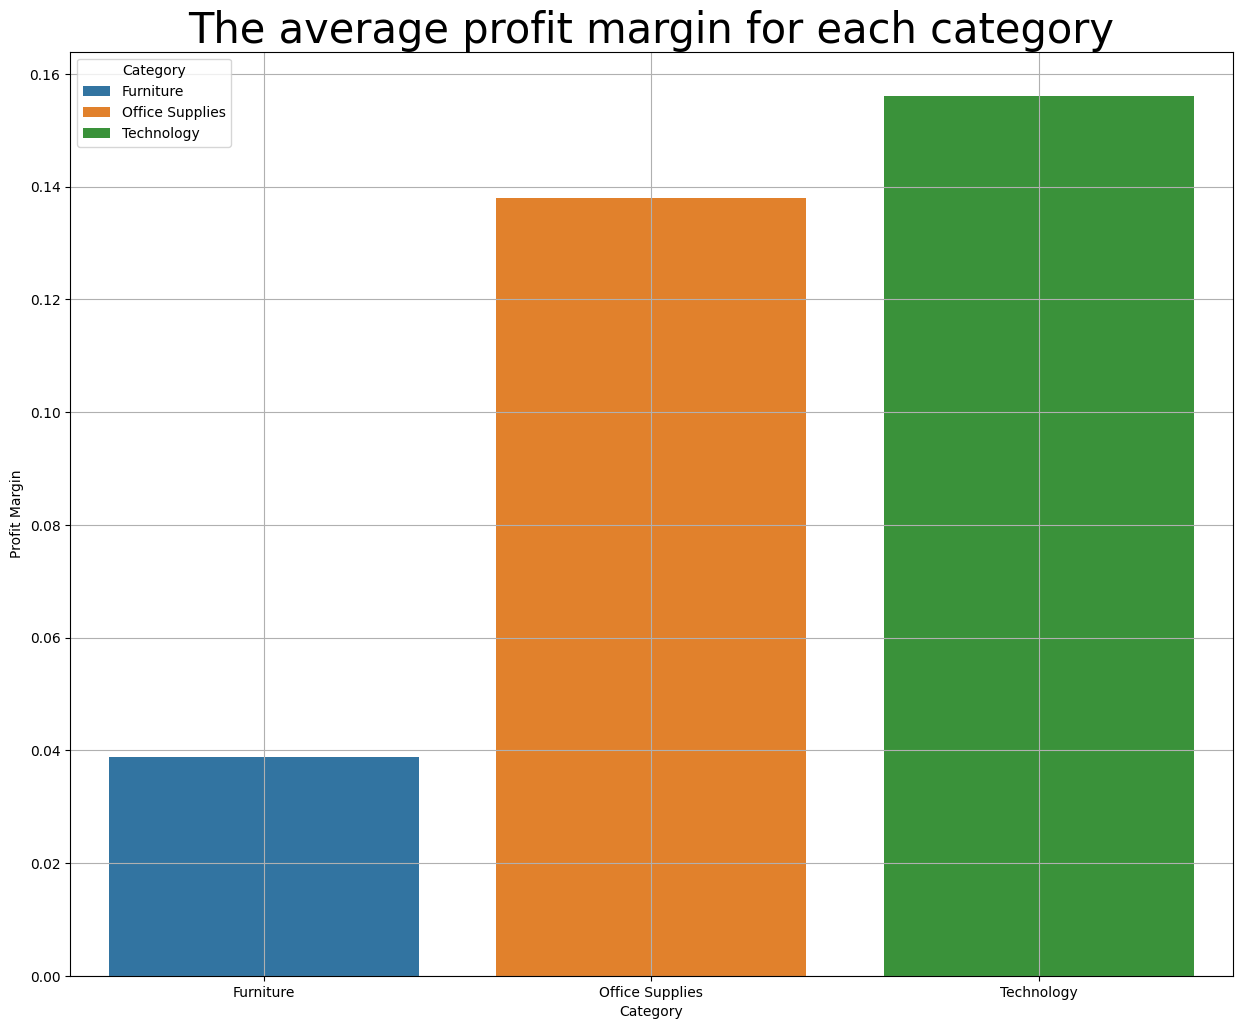

In [ ]:
# The average profit margin for each category
data['Profit Margin'] = data['Profit'] / data['Sales']


avg_profit_margin_by_category= data.groupby(['Category'], as_index=False)['Profit Margin'].mean()


plt.figure(figsize=(15,12))

sns.barplot(data=avg_profit_margin_by_category, x='Category', y='Profit Margin',hue='Category',legend=True)

plt.title('The average profit margin for each category', size=30)
plt.grid()
plt.show()

## 10. Analyse des Segments Clients et Modes de Livraison

Customers

In [ ]:
data['Segment'].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

In [ ]:
data['Ship Mode'].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

In [ ]:
pivot_table_by_sales = data.pivot_table(index='Segment',columns='Ship Mode', values='Sales',aggfunc='sum' )
pivot_table_by_sales

Ship Mode,First Class,Same Day,Second Class,Standard Class
Segment,,,,
Consumer,159168.9650,60596.359,231498.9496,710137.0714
Corporate,105858.4699,45121.323,146126.0388,409040.5351
Home Office,86400.9880,22645.443,81568.5810,239038.1365


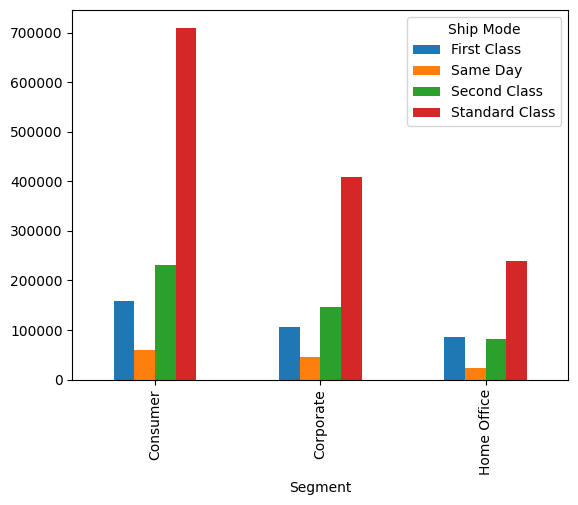

In [ ]:
pivot_table_by_sales.plot(kind='bar', stacked=False)
plt.show()

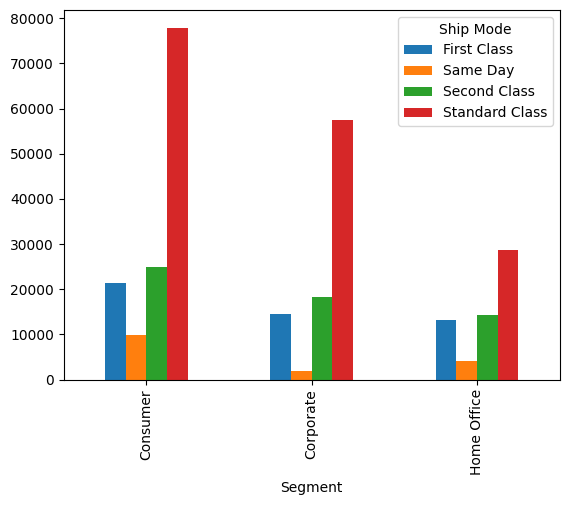

In [ ]:
pivot_table_by_profit=data.pivot_table(index='Segment', columns='Ship Mode', values='Profit',aggfunc='sum')
pivot_table_by_profit.plot(kind='bar')

plt.show()

### 10.1 Ventes et Profits par Segment Client et Mode de Livraison

Most of the sales and profit come from (Consumers) Who are use (standard-class) shipping mode